In [9]:
import sys
import os
sys.path.append(os.path.abspath('../src'))
from models.cnn_model import *
from utils.visualization import *
from data.preprocessing import extract_observations_from_shapefile
from flax.training import checkpoints
jax.config.update('jax_platform_name', 'cpu')
# =======================
# Initialize base model
# =======================
rng = jax.random.PRNGKey(0)
learning_rate = 1e-3
optimizer = optax.adam(learning_rate)

correlation_map_train = np.load("../data/calibration/correlation_map_train.npy")
X_train = np.load("../data/calibration/x_cov.npy")

model = CNNModel(use_correlation=False)
params = model.init(rng, X_train[:1], get_correlation_map_batch(correlation_map_train, 1))
state = TrainState.create(apply_fn=model.apply, params=params, tx=optimizer)

# =======================
# Restore from checkpoint
# =======================
#ckpt_dir = os.path.abspath("../notebooks/checkpoints_nn")
ckpt_dir = os.path.abspath("D:/Proyectos_GitHub/adao_tests/notebooks/checkpoints_nn")
state = checkpoints.restore_checkpoint(ckpt_dir=ckpt_dir, target=state)

print("✅ State restored from the most recent checkpoint.")

✅ State restored from the most recent checkpoint.


In [10]:
# Set the standard deviation for Gaussian noise
sigma = 0.1

# Load dummy covariate data (shape: x, y, n)
x_cov = np.load("../data/calibration/x_cov.npy")  # dummy covariate (x, y, n)

# Load true image and add Gaussian noise
noise = np.random.normal(loc=0, scale=sigma, size=(387, 450, 1))
true_image = np.load("../data/calibration/y_true.npy") + noise
true_image = np.squeeze(true_image)  # remove single-dimensional entries

# Load correlation map and convert to JAX array
correlation_map = jnp.array(np.load("../data/calibration/correlation_map_train.npy"))

# Extract observed values and corresponding coordinates from shapefile
pixel_x, pixel_y, coords_x, coords_y, observed_values = extract_observations_from_shapefile(
    shp_file="../data/calibration_points/calibration_points.shp",
    tiff_file="../data/Tiff_reference_only/depth_0.010_0.055.tiff",
    X_data=x_cov,
    depth_true=true_image
)

The observed function is modeled as:

$$
z(x) = S(x, \theta) + \delta(x) + \varepsilon(x)
$$

with:

$$
\delta(x) \sim \mathcal{GP}\left(\beta_1 x + \beta_2 y,\; \sigma_\delta^2 \exp\left[-\omega_x (x_i - x_i')^2 - \omega_y (y_i - y_i')^2\right]\right)
$$

$$
\varepsilon(x) \sim \mathcal{N}(0,\; \sigma^2 I)
$$


# Model Inadequacy = 0

In [11]:
model1 = build_model(x_cov, state, correlation_map, true_image, coords_y, coords_x, pixel_x, pixel_y, observed_values, use_discrepancy=False)
with model1:
    step = pm.Slice()
    trace1 = pm.sample(
        draws=100,
        tune=20,
        chains=4,
        cores=10,
        step=step,
        idata_kwargs={"log_likelihood": False}
    )


Multiprocess sampling (4 chains in 4 jobs)
INFO:pymc.sampling.mcmc:Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
INFO:pymc.sampling.mcmc:CompoundStep
>Slice: [n1]
INFO:pymc.sampling.mcmc:>Slice: [n1]
>Slice: [n2]
INFO:pymc.sampling.mcmc:>Slice: [n2]
>Slice: [sigma]
INFO:pymc.sampling.mcmc:>Slice: [sigma]


Output()

Sampling 4 chains for 20 tune and 100 draw iterations (80 + 400 draws total) took 325 seconds.
INFO:pymc.sampling.mcmc:Sampling 4 chains for 20 tune and 100 draw iterations (80 + 400 draws total) took 325 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
INFO:pymc.stats.convergence:The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
ERROR:pymc.stats.convergence:The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [14]:
# 🔹 Get statistical summary of the MCMC trace
summary = az.summary(trace1)

# ✅ Display the summary
summary

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
n1,0.032,0.002,0.029,0.035,0.000,0.000,413.0,306.0,1.01
n2,0.077,0.008,0.060,0.085,0.000,0.000,325.0,254.0,1.01
sigma,0.132,0.022,0.097,0.178,0.001,0.001,368.0,282.0,1.00


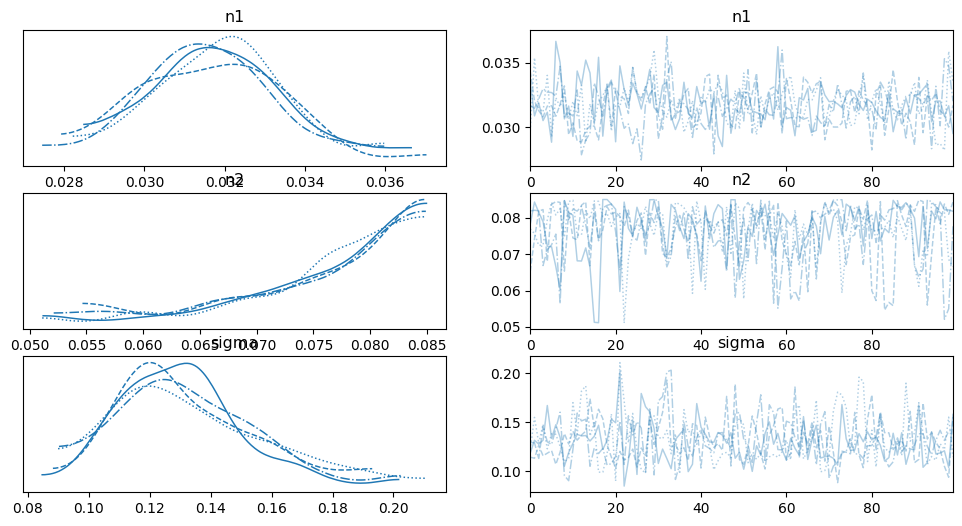

In [15]:
az.plot_trace(trace1)
plt.show()

# Model Inadequacy

$\beta_1 x + \beta_2 y$, with true values $\beta_{1,\text{true}} = 0.3$ and $\beta_{2,\text{true}} = 0.8$


In [19]:
# Set standard deviation for Gaussian noise
sigma = 0.1

# Generate Gaussian noise
ruido = np.random.normal(loc=0, scale=sigma, size=(387, 450, 1))

# 🔹 Load data ensuring float64 type
x_cov = np.load("../data/calibration/x_cov.npy")  # X_train[0,:,:,:]

# Define true coefficients for model inadequacy
b1_true = 0.3
b2_true = 0.8

# Load true image and add noise
true_image = np.load("../data/calibration/y_true.npy") + ruido

# Load correlation map and convert to JAX array
correlation_map = jnp.array(np.load("../data/calibration/correlation_map_train.npy"))

# ✅ Ensure true_image has the correct shape and apply model inadequacy
true_image = np.squeeze(true_image) + b1_true * x_cov[:, :, 1] + b2_true * x_cov[:, :, 2]

# Extract observed values and coordinates from shapefile
pixel_x, pixel_y, coords_x, coords_y, observed_values = extract_observations_from_shapefile(
    shp_file="../data/calibration_points/calibration_points.shp",
    tiff_file="../data/Tiff_reference_only/depth_0.010_0.055.tiff",
    X_data=x_cov,
    depth_true=true_image
)

In [20]:
model2 = build_model(x_cov, state, correlation_map, true_image, coords_y, coords_x, pixel_x, pixel_y, observed_values, use_discrepancy=True)
with model1:
    step = pm.Slice()
    trace2 = pm.sample(
        draws=100,
        tune=20,
        chains=4,
        cores=10,
        step=step,
        idata_kwargs={"log_likelihood": False}
    )

Multiprocess sampling (4 chains in 4 jobs)
INFO:pymc.sampling.mcmc:Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
INFO:pymc.sampling.mcmc:CompoundStep
>Slice: [n1]
INFO:pymc.sampling.mcmc:>Slice: [n1]
>Slice: [n2]
INFO:pymc.sampling.mcmc:>Slice: [n2]
>Slice: [sigma]
INFO:pymc.sampling.mcmc:>Slice: [sigma]


Output()

Sampling 4 chains for 20 tune and 100 draw iterations (80 + 400 draws total) took 317 seconds.
INFO:pymc.sampling.mcmc:Sampling 4 chains for 20 tune and 100 draw iterations (80 + 400 draws total) took 317 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
INFO:pymc.stats.convergence:The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
ERROR:pymc.stats.convergence:The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [21]:
# 🔹 Get statistical summary of the MCMC trace
summary = az.summary(trace2)

# ✅ Display the summary
summary

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
n1,0.032,0.002,0.028,0.035,0.000,0.000,368.0,281.0,1.01
n2,0.077,0.007,0.065,0.085,0.000,0.001,334.0,196.0,1.01
sigma,0.132,0.021,0.097,0.172,0.001,0.001,358.0,307.0,1.00


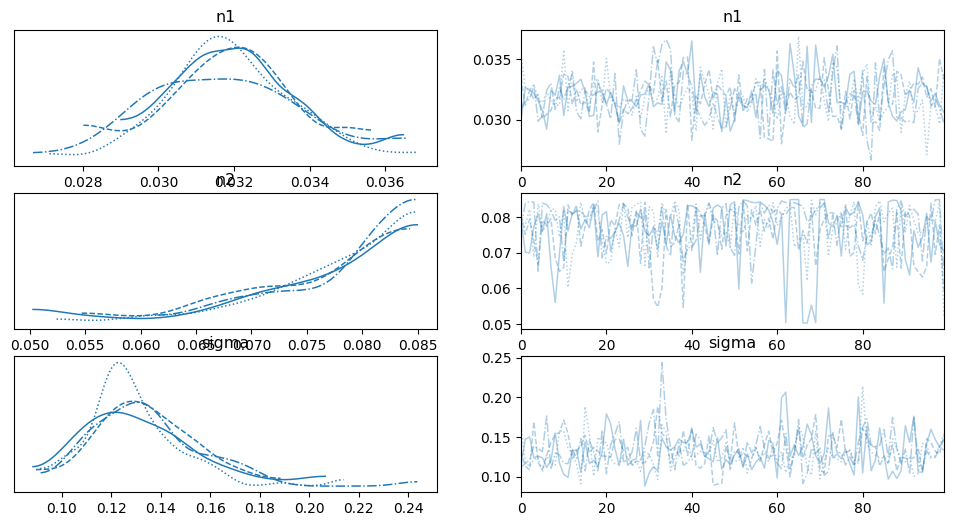

In [22]:
az.plot_trace(trace2)
plt.show()